# 📊 Sales Data Analysis Project

**Objective:**  
Analyze sales performance to identify trends, top products, and high-performing regions using Python, SQL-style queries, and visualization.

**Tools Used:**  
- Python (Pandas, Matplotlib, Seaborn)
- SQL-style queries (pandasql)
- Power BI (Dashboard)


## 1️⃣ Import Required Libraries


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandasql as ps


## 2️⃣ Load Sales Dataset


In [47]:
import pandas as pd

df = pd.read_csv("sales_data.csv")

# Convert Order Date with dayfirst=True
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True,
    errors='coerce'
)

# Create Month column
df['Month'] = df['Order Date'].dt.to_period('M')

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017-11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017-11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017-06
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016-10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016-10


## 3️⃣ Data Overview & Cleaning


In [48]:
df.info()
df.isnull().sum()
df['Order Date'].isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

np.int64(0)

## 4️⃣ Date Conversion & Feature Engineering


In [49]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')


In [66]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month'],
      dtype='object')


## 5️⃣ Monthly Sales Trend Analysis


In [53]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)
monthly_sales


,Month,Sales
0,2015-01,14205.7070
1,2015-02,4519.8920
2,2015-03,55205.7970
3,2015-04,27906.8550
4,2015-05,23644.3030
5,2015-06,34322.9356
6,2015-07,33781.5430
7,2015-08,27117.5365
8,2015-09,81623.5268
9,2015-10,31453.3930


## 6️⃣ Top Selling Products Analysis


In [54]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

## 7️⃣ Region-wise Sales Analysis 


In [57]:
top_regions = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

top_regions


Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

## 8️⃣ Data Visualization


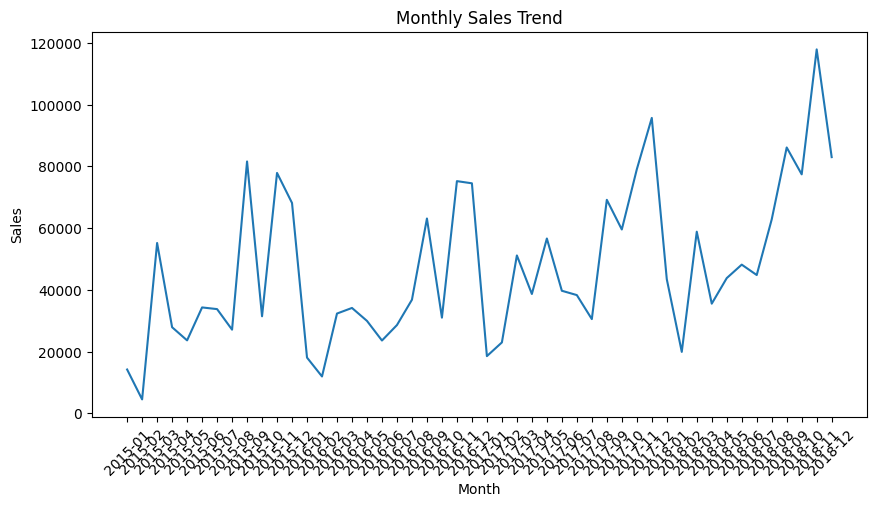

In [58]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.show()


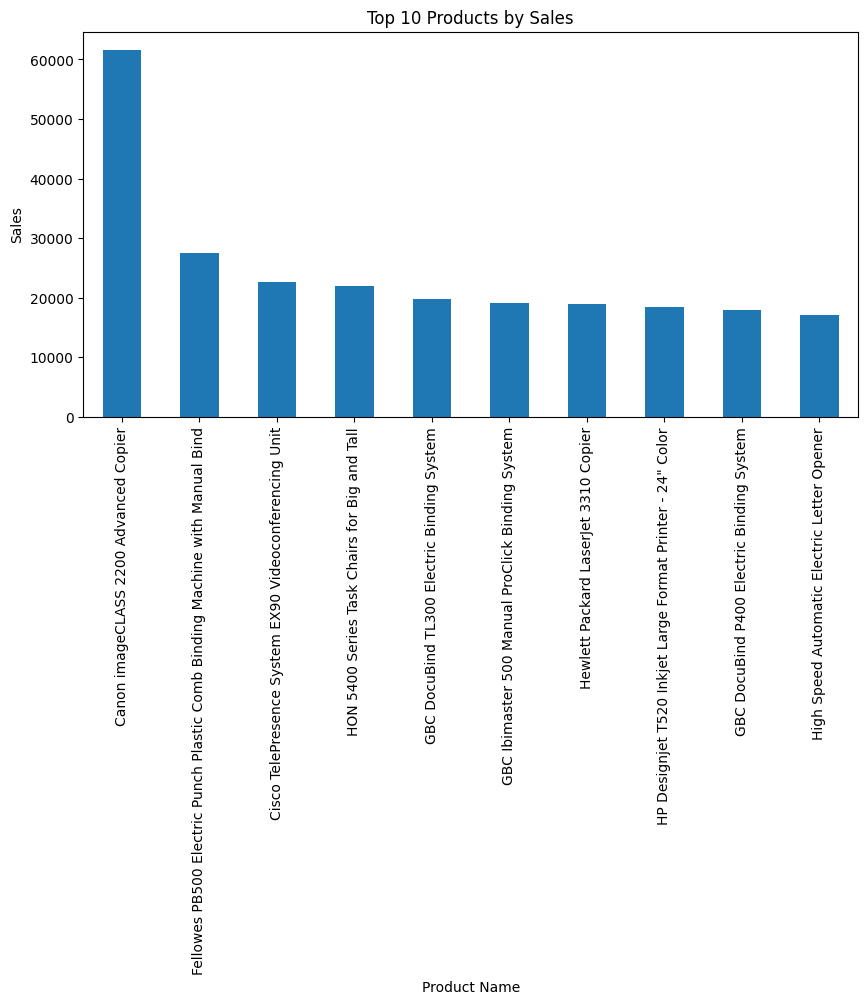

In [59]:
top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()


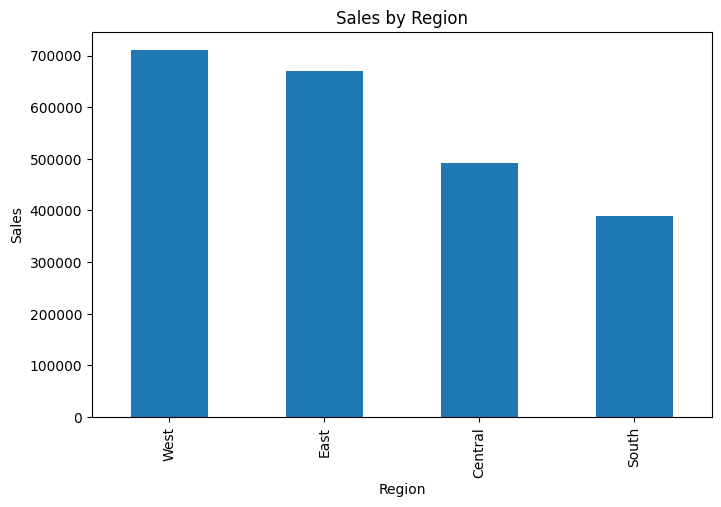

In [60]:
top_regions.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()


## 9️⃣ Export Data for Power BI Dashboard


In [65]:
monthly_sales.to_csv("monthly_sales.csv", index=False)
top_products.reset_index().to_csv("top_products.csv", index=False)
top_regions.to_csv("top_regions.csv", index=False)


## 🔍 Key Insights & Business Conclusions

- Sales show clear seasonal trends across months  
- Certain products contribute disproportionately to total revenue  
- The highest sales come from specific regions, enabling targeted marketing  
- Data is Power BI ready for executive dashboards


## 🔮 Sales Forecasting Using Machine Learning (Linear Regression)

A simple regression model is used to forecast future sales based on historical monthly trends.


### 📦 Import Required Libraries


In [68]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


### 🛠️ Prepare Data for Forecasting

Each month is converted into a numerical index so it can be used by the regression model.


In [69]:
monthly_sales['Month_num'] = np.arange(len(monthly_sales))

X = monthly_sales[['Month_num']]
y = monthly_sales['Sales']


### 🤖 Train Linear Regression Model


In [70]:
model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 📈 Forecast Next 6 Months of Sales


In [71]:
# Generate future month indices
future_months = np.arange(len(monthly_sales), len(monthly_sales) + 6)
future_df = pd.DataFrame({'Month_num': future_months})

# Predict future sales
forecast_sales = model.predict(future_df)

# Generate future month labels correctly
last_month = pd.Period(monthly_sales['Month'].iloc[-1], freq='M')

forecast_df = pd.DataFrame({
    'Month': pd.period_range(start=last_month + 1, periods=6, freq='M').astype(str),
    'Forecasted Sales': forecast_sales
})

forecast_df


,Month,Forecasted Sales
0,2019-01,68878.998333
1,2019-02,69767.310525
2,2019-03,70655.622716
3,2019-04,71543.934908
4,2019-05,72432.247100
5,2019-06,73320.559291


### 📊 Visualize Actual vs Forecasted Sales


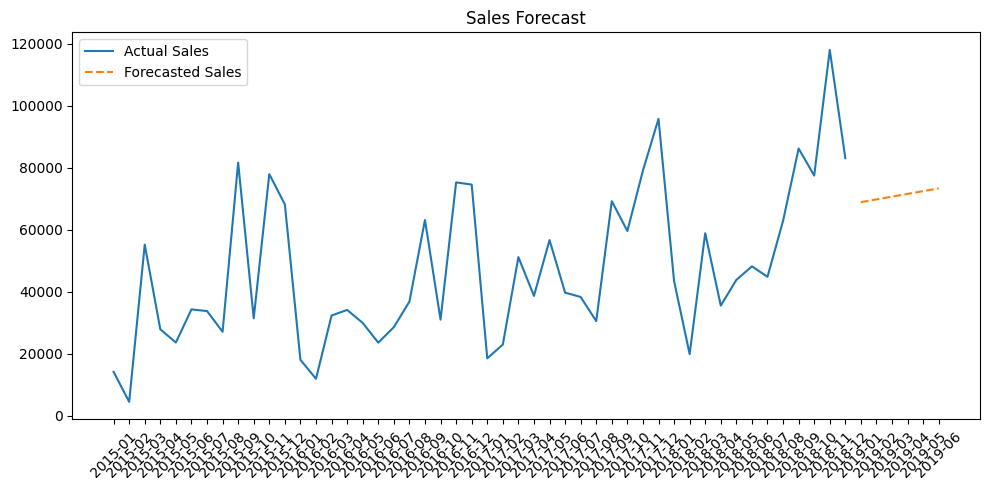

In [73]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['Month'].astype(str),
    monthly_sales['Sales'],
    label="Actual Sales"
)

plt.plot(
    forecast_df['Month'],
    forecast_df['Forecasted Sales'],
    label="Forecasted Sales",
    linestyle='--'
)

plt.xticks(rotation=45)
plt.legend()
plt.title("Sales Forecast")
plt.tight_layout()
plt.show()


## 🧮 SQL-Style Region-Wise Sales Analysis

SQL queries are executed on Pandas DataFrames using pandasql to demonstrate SQL proficiency.


### 🗺️ Region-Wise Sales Query (SQL Style)


In [78]:
df['Month'] = df['Month'].astype(str)


In [79]:
import pandasql as ps

query = """
SELECT 
    Region,
    SUM(Sales) AS Total_Sales
FROM df
GROUP BY Region
ORDER BY Total_Sales DESC
"""

region_sales_sql = ps.sqldf(query, locals())
region_sales_sql


,Region,Total_Sales
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


## ✅ Project Summary

This project demonstrates:
- End-to-end sales data analysis
- SQL-style querying on real datasets
- Business-focused insights
- Sales forecasting using machine learning
- Power BI–ready outputs
